# Trabajo Práctico 4: Aprendizaje No-Supervisado

In [2]:
from src.pca import standardize, fit_pca, transform_pca, reconstruct_pca
%load_ext autoreload
%autoreload 2
import pandas as pd
import numpy as np
from src.utils import DATA_PATH, RANDOM_SEED, train_val_split, df_to_np
from src.plots import plot_images, plot_class_distribution, plot_images_by_class, plot_explained_variance, \
    plot_reconstruction_comparison
from src.pca import standardize, fit_pca

np.random.seed(RANDOM_SEED)

## 1. Inspección de los datos

**a) Implementar una función que pueda graficar un número
   arbitrario de imágenes del dataset. Mostrar un ejemplo
   de un gráfico con 15 imágenes seleccionadas de manera
  aleatoria. Esta función va a ser necesaria a lo largo
  de todo el trabajo, por lo que se deberá ir adaptando
  de acuerdo a las necesidades que vayan surgiendo.**

In [3]:
df = pd.read_csv(DATA_PATH)

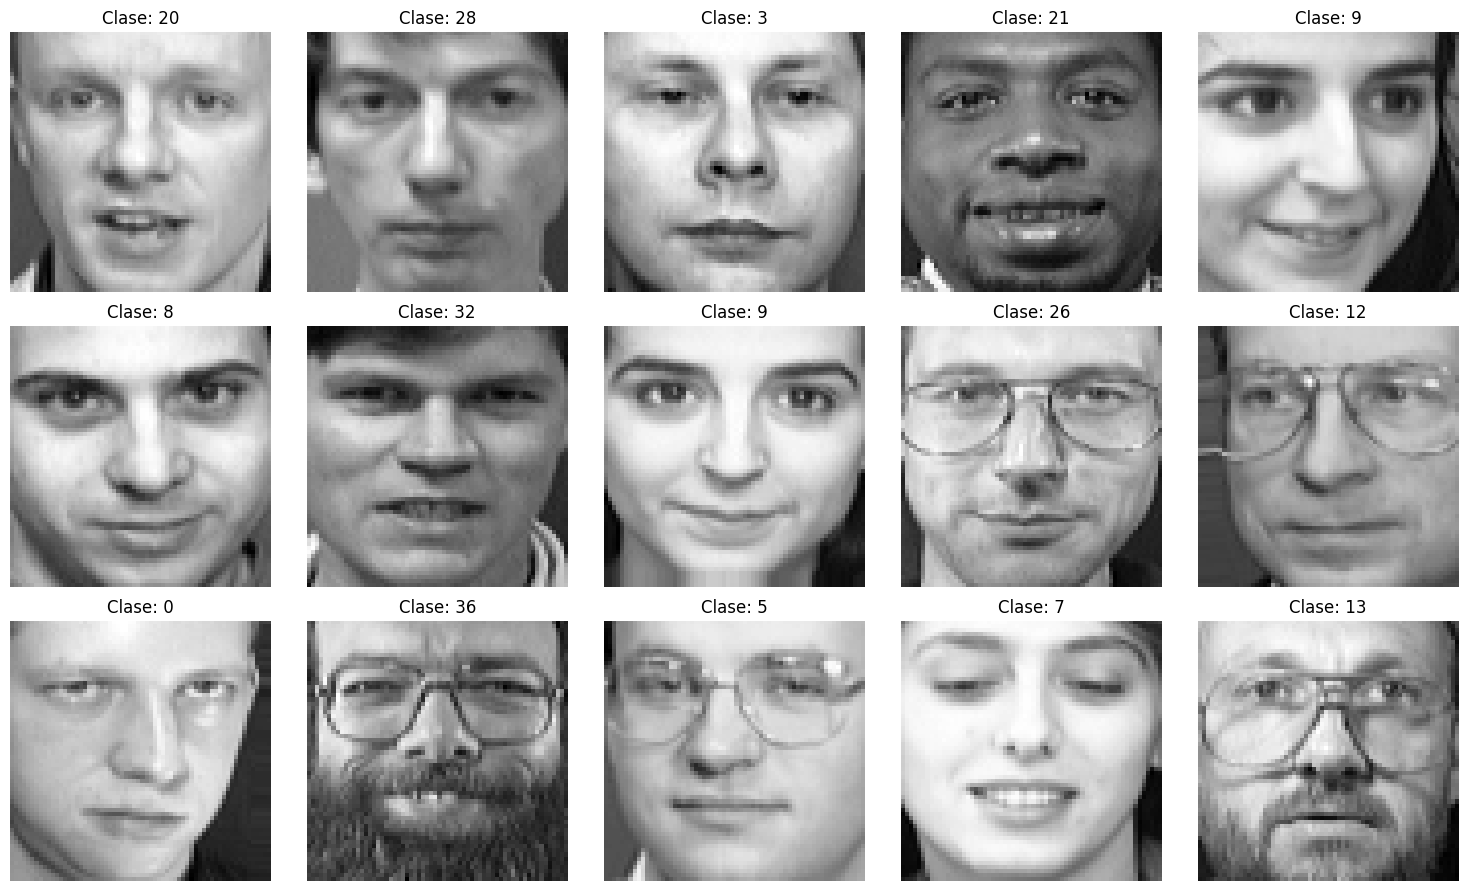

In [4]:
plot_images(df, n=15, ncols=5, filename="1_initial_faces")

**b) Realizar un analisis exploratorio enfocado en
  la distribución de clases en los datos. Para
  tener una mejor noción de la variabilidad de las
  muestras, graficar muestras agrupadas por clase,
  para al menos 5 clases.**

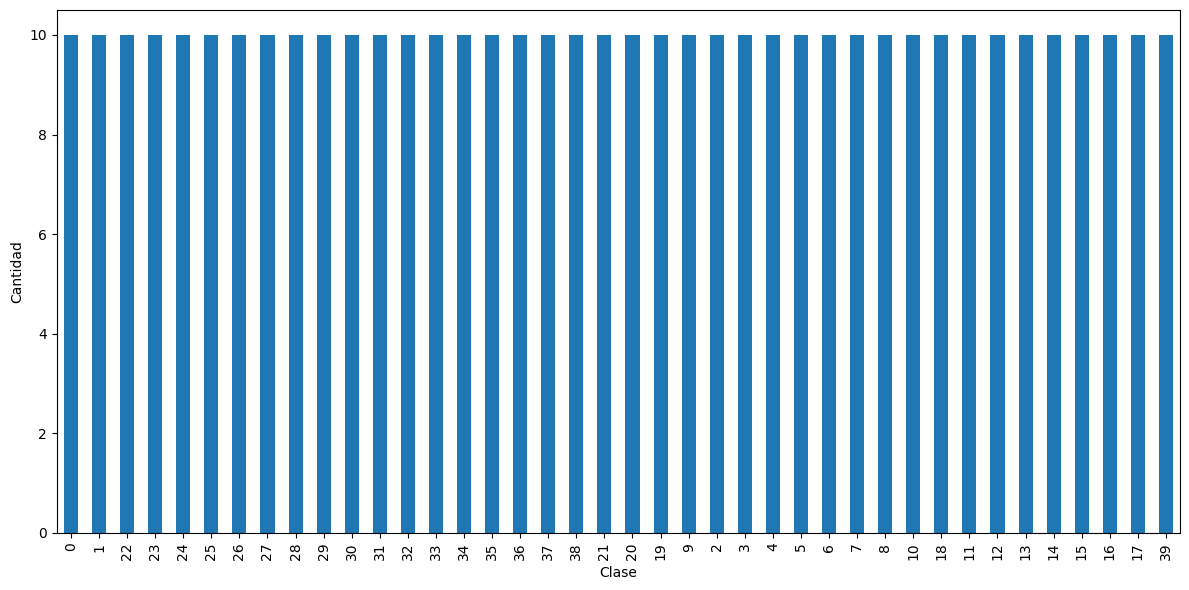

In [5]:
plot_class_distribution(df, figsize=(12,6), filename="2_class_distribution")

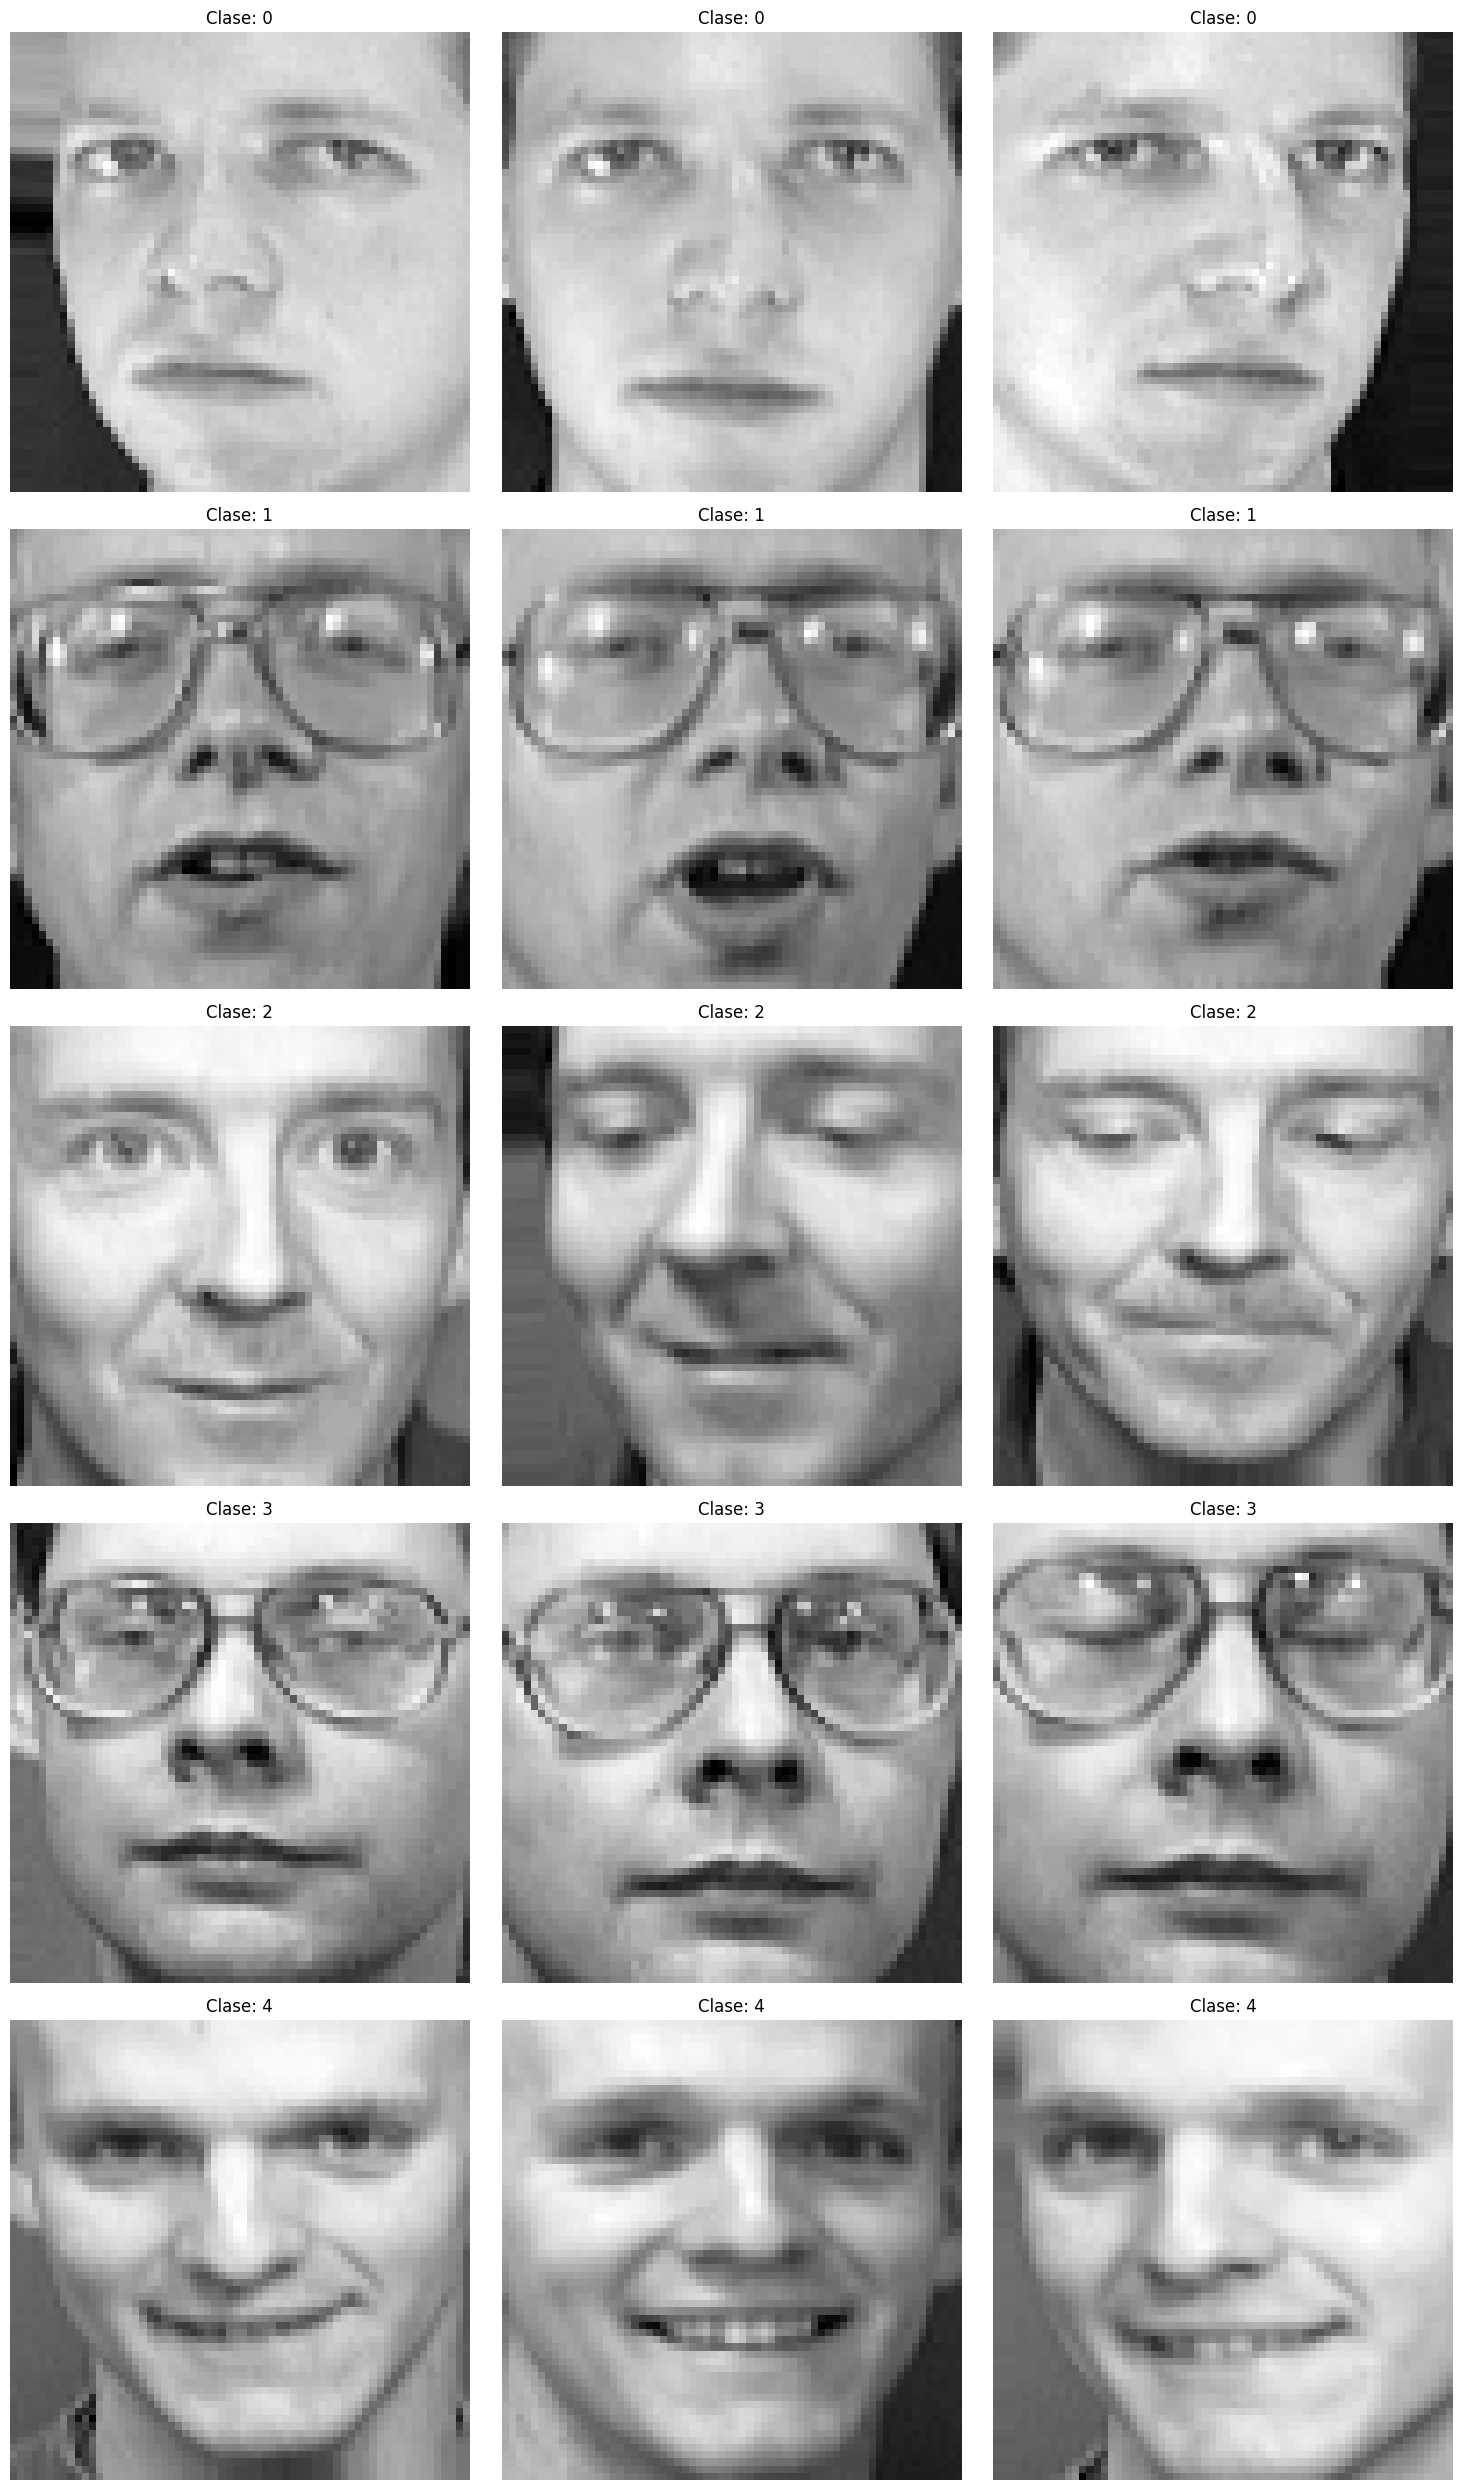

In [6]:
plot_images_by_class(df, n_classes=5, n_per_class=3, filename="3_initial_faces_by_class")

  **c) Realizar un split de datos estratificado para
  conformar un conjunto de entrenamiento y otro de
  evaluación, en donde los datos de evaluación sean
   el 20 % del total.**

In [7]:
df_train, df_val = train_val_split(df, val_size=0.2)
df_train.shape

(320, 4097)

## 2. Reducción de dimensionalidad

**a) Implementar una función para estandarizar los
  datos, y otra para realizar Principal Component
  Analysis (PCA). Estandarizar y aplicar PCA sobre
  los datos de entrenamiento. Con la transformacion
   aprendida previamente reducir la dimensionalidad
   de los datos de evaluacion.**

In [8]:
# primero convertimos a numpy
X, y = df_to_np(df_train)

# estandarizamos
X_std, X_mu, X_sigma = standardize(X)

# calculamos:
# W = autovectores como columnas
# lambdas = autovalores
# varianza explicada por cada componente principal
lambdas, W, explained_variance_ratios = fit_pca(X_std)

# transformamos sin reducir dimensionalidad
Z_full = transform_pca(X_std, W)

b) Realizar un gráfico que muestre la varianza
  explicada acumulada en función del número de
  componentes. Conservar el número de componentes
  que aseguren explicar el 90 % de la varianza de
  los datos. Utilizando la función aprendida en el
  punto 1.a), realizar un gráfico comparativo entre
   las imágenes originales y la reconstrucción
  partiendo del número de componentes determinado
  anteriormente.

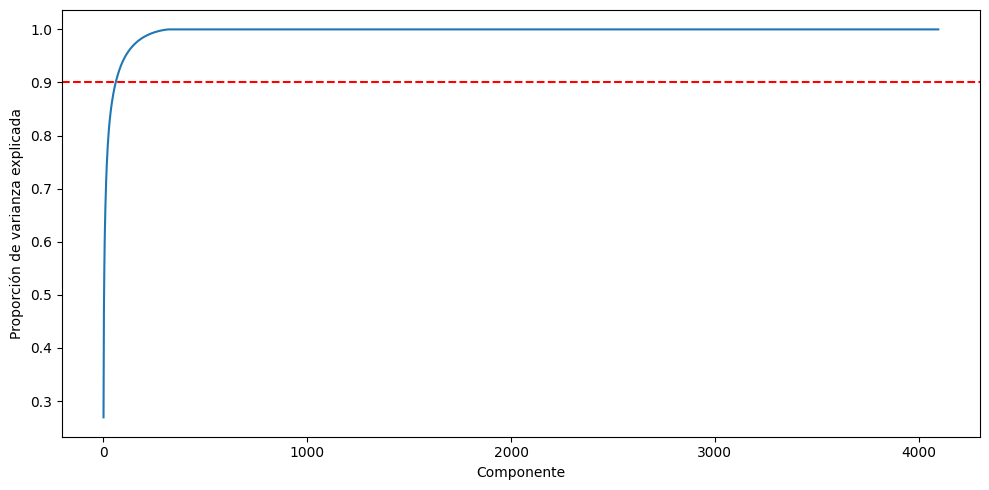

In [9]:
plot_explained_variance(explained_variance_ratios, filename="4_explained_variance")

In [13]:
threshold_component = np.argmax(np.cumsum(explained_variance_ratios) >= 0.90) + 1

print(f"Las primeras {threshold_component} componentes principales explican el 90% de la varianza")

Las primeras 61 componentes principales explican el 90% de la varianza


In [20]:
n_components = threshold_component
Z_reduced = transform_pca(X_std, W, int(n_components))
X_reconstructed = reconstruct_pca(Z_reduced, W, X_mu, X_sigma, n_components)

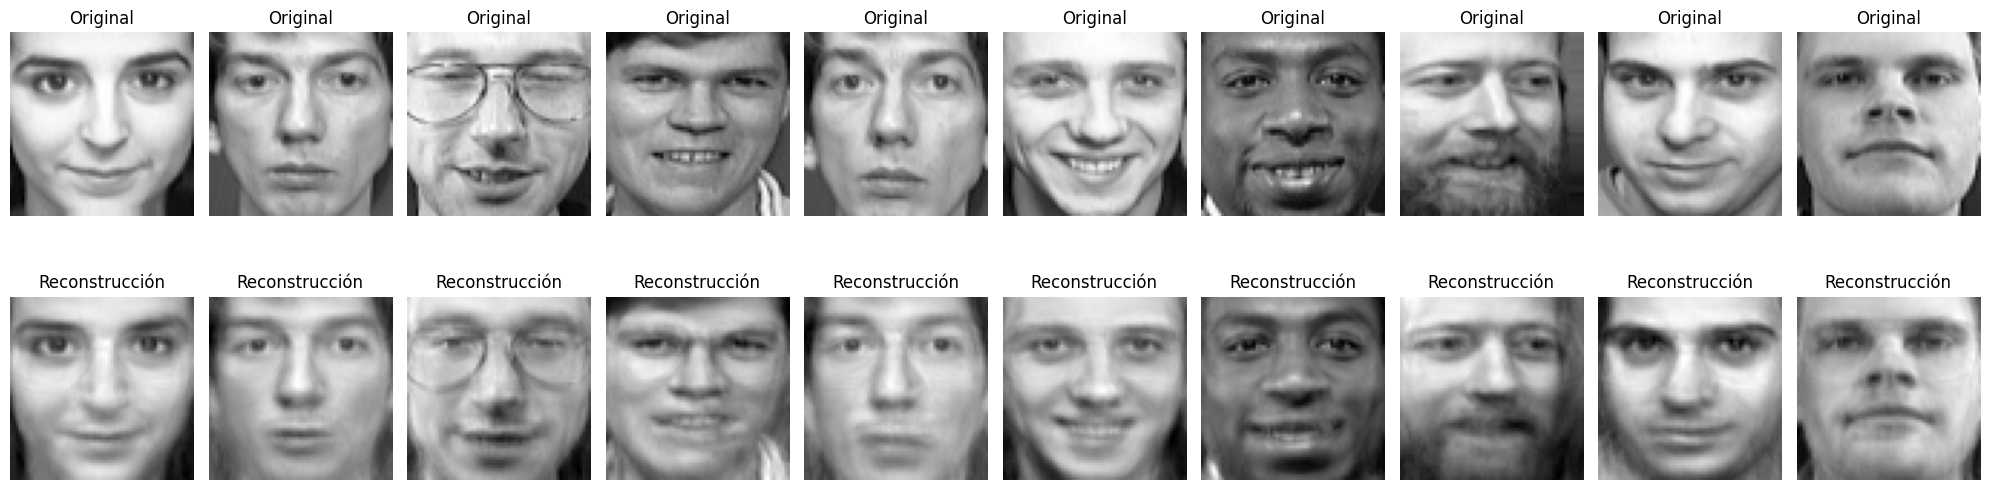

In [21]:
plot_reconstruction_comparison(X, X_reconstructed, n_images=10, filename="5_reconstruction_comparison")

**c) Entrenar un modelo de autoencoder
  deterministico (AE) utilizando la librería
  PyTorch para armar y entrenar las redes
  neuronales involucradas (la red de encoder y la
  de decoder). Para hacer una comparacion justa, la
   dimension latente debe ser la misma que la
  obtenida en el PCA. Recuerde dividir el conjunto
  de datos en dos subconjuntos: entrenamiento y
  validación, los mismos utilizados para el PCA. El
   subconjunto de entrenamiento se empleará para
  entrenar el AE, mientras que el de validación
  servirá para ajustar los hiperparámetros
  (regularizacion, arquitectura o lo que considere)
   y evaluar el error de reconstrucción.**